# 03 - Von Heijne method

**Aim:** implement signal-peptide detection using the representative datasets prepared in 02b.

We load the prepared proteins and select the training, validation and test folds for the first cross-validation round. We estimate a cleavage-site weight matrix from training positives and score both classes in the validation fold. We display the matrix and compare the validation score distributions.

**Materials**
- `03-Methods-vonHeijne-2026.pdf` (slides 4–17 and 24)


## 0. Imports and paths

Paths are relative to `notebooks/`. We use the prepared FASTA and TSV files from 02b, retaining their original metadata and split/fold assignments.

As in 02c, plotting cells save numbered PDFs in `results/figures/03/`, print their paths and display the figures. Filenames identify the current CV round by its test fold; rerunning a cell updates that file.


In [39]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

input_dir = Path("../data/prepared")

sns.set_theme()
figure_dir = Path("../results/figures/03")
figure_dir.mkdir(parents=True, exist_ok=True)


## 1. Data preparation and CV split

### 1.1 Load sequences and metadata

We reuse the FASTA reader from 02b and attach sequences by accession. Labels are 1 for SP and 0 for NO_SP. Cross-validation uses only the saved training split; benchmarking remains separate. Fold identifiers stay 1–5.


In [40]:
def read_fasta(fasta_path):
    sequences = {}
    with open(fasta_path, encoding="utf-8") as fasta_in:
        for line in fasta_in:
            line = line.strip()
            if line.startswith(">"):
                accession = line[1:].split()[0]
                sequences[accession] = ""
            elif line:
                sequences[accession] += line
    return sequences


positive_data = pd.read_csv(
    input_dir / "positive_dataset.tsv", sep="\t", dtype={"cv_fold": "Int64"}
)
negative_data = pd.read_csv(
    input_dir / "negative_dataset.tsv", sep="\t", dtype={"cv_fold": "Int64"}
)
positive_sequences = read_fasta(input_dir / "positive_dataset.fasta")
negative_sequences = read_fasta(input_dir / "negative_dataset.fasta")

positive_data["sequence"] = positive_data["accession"].map(positive_sequences)
negative_data["sequence"] = negative_data["accession"].map(negative_sequences)
positive_data["label"] = 1
negative_data["label"] = 0

prepared_data = pd.concat([positive_data, negative_data], ignore_index=True)
data = prepared_data[prepared_data["split"] == "training"].copy()
benchmarking_data = prepared_data[prepared_data["split"] == "benchmarking"].copy()


### 1.2 Select folds for one round

Following slide 24, the test fold is followed cyclically by the validation fold; the remaining three folds train the matrix. For example, test fold 1 uses validation fold 2 and training folds 3–5. The helper also restricts its input to the training split, keeping benchmarking outside cross-validation.


In [41]:
def get_cv_split(data, test_fold):
    cv_data = data[data["split"] == "training"]
    validation_fold = test_fold % 5 + 1
    train = cv_data[~cv_data["cv_fold"].isin([test_fold, validation_fold])].copy()
    validation = cv_data[cv_data["cv_fold"] == validation_fold].copy()
    test = cv_data[cv_data["cv_fold"] == test_fold].copy()
    return train, validation, test


### 1.3 Extract training cleavage contexts

We extract `sequence[c-13:c+2]` only from positive proteins in the round's training subset (slide 12). The one-based `cleavage_pos` is the last SP residue, as in 02c. Contexts retain non-canonical residues at their original positions; the matrix counts only canonical observations. Proteins without a complete 15-residue context are recorded separately.

We do not train from the full `training_cleavage_sites.fasta`, which includes positives from all five folds.


In [42]:
def extract_cleavage_contexts(train):
    contexts = []
    excluded = []
    positives = train[train["label"] == 1]
    for row in positives.itertuples(index=False):
        c = int(row.cleavage_pos)
        if c < 13 or c + 2 > len(row.sequence):
            excluded.append(row.accession)
            continue
        contexts.append({
            "accession": row.accession,
            "cv_fold": row.cv_fold,
            "context": row.sequence[c - 13:c + 2],
        })
    return pd.DataFrame(contexts, columns=["accession", "cv_fold", "context"]), excluded


## 2. Build the weight matrix

We count 15-residue positive contexts spanning −13…−1,+1,+2, with pseudocount 1 (slides 9 and 12). Non-canonical residues are ignored without shifting positions. Each column is normalized over its canonical observations plus 20 pseudocounts; for canonical contexts this equals N + 20.

We normalize the SwissProt composition recorded in 02c and calculate log-odds using natural logarithms. Only positive contexts from the three training folds contribute to the matrix (slide 24).


In [43]:
def build_pswm(contexts_df, background_freqs=None):
    aa_alphabet = sorted("ACDEFGHIKLMNPQRSTVWY")
    n_positions = 15  
    
    if background_freqs is None:
        background_freqs = {
            "A": 8.25, "C": 1.38, "D": 5.46, "E": 6.71, "F": 3.86,
            "G": 7.07, "H": 2.27, "I": 5.90, "K": 5.79, "L": 9.64,
            "M": 2.41, "N": 4.06, "P": 4.75, "Q": 3.93, "R": 5.52,
            "S": 6.66, "T": 5.36, "V": 6.85, "W": 1.10, "Y": 2.92,
        }
        
    counts = np.ones((len(aa_alphabet), n_positions))
    aa_to_index = {aa: idx for idx, aa in enumerate(aa_alphabet)}
    
    for context_str in contexts_df["context"]:
        for pos_idx, aa in enumerate(context_str):
            if aa in aa_to_index:
                counts[aa_to_index[aa], pos_idx] += 1
                
    pspm = counts / counts.sum(axis=0)
    bg_vector = np.array([background_freqs[aa] for aa in aa_alphabet]).reshape(-1, 1)
    
    bg_vector = bg_vector / bg_vector.sum()

    pswm_array = np.log(pspm / bg_vector)

    position_labels = [f"P{i}" for i in range(-13, 3) if i != 0]
    pswm_df = pd.DataFrame(pswm_array, index=aa_alphabet, columns=position_labels)
    
    return pswm_df


### 2.1 Build the matrix for the first round

We select test fold 1, validation fold 2 and training folds 3–5. Only positive proteins in those three training folds supply the cleavage-site contexts used to build this matrix. Validation and test proteins do not contribute to its estimation.


In [44]:
test_fold = 1
train, validation, test = get_cv_split(data, test_fold=test_fold)
contexts, excluded_contexts = extract_cleavage_contexts(train)
pswm_matrix = build_pswm(contexts)

print("Test fold:", test_fold)
print("Validation fold:", test_fold % 5 + 1)
print("Training folds:", sorted(train["cv_fold"].unique().tolist()))
print("Training cleavage contexts:", len(contexts))
print("Excluded incomplete contexts:", len(excluded_contexts))


Test fold: 1
Validation fold: 2
Training folds: [3, 4, 5]
Training cleavage contexts: 528
Excluded incomplete contexts: 0


### 2.2 Inspect the training weight matrix

We display the 20 × 15 matrix learned from the three training folds of this round. Rows identify amino acids and columns identify positions around the cleavage site. Positive weights indicate enrichment relative to SwissProt; negative weights indicate depletion. Values are rounded only for display.


In [45]:
pswm_matrix.round(3)


,P-13,P-12,P-11,P-10,P-9,P-8,P-7,P-6,P-5,P-4,P-3,P-2,P-1,P1,P2
A,0.213,0.315,0.195,0.079,0.752,0.793,0.436,0.752,0.676,0.298,1.205,0.016,1.826,0.665,-0.634
C,1.154,0.809,1.067,0.541,0.615,1.410,1.195,0.920,0.541,0.748,1.559,0.173,1.020,0.278,0.173
D,-2.707,-3.400,-3.400,-3.400,-2.707,-2.013,-2.301,-1.454,-0.761,-0.835,-3.400,-0.032,-2.301,0.289,0.002
E,-2.220,-3.606,-2.913,-2.913,-2.220,-2.220,-2.220,-1.814,-0.967,-0.715,-2.220,0.083,-2.220,0.201,0.244
F,0.685,0.754,0.348,0.859,0.502,0.558,0.731,0.444,-0.488,-0.008,-3.053,-0.414,-2.360,-0.280,-0.280
G,-0.950,-0.950,-0.714,-0.614,-0.480,-0.614,-0.523,-0.662,0.605,0.436,0.171,-0.714,0.967,-0.291,-0.439
H,-2.522,-2.522,-1.829,-1.829,-0.913,-1.423,-1.136,-0.576,0.368,-0.913,-1.829,0.656,-2.522,0.186,0.474
I,0.134,0.284,0.284,0.160,-0.481,-0.644,-0.110,0.330,-1.079,-0.838,-0.342,-0.912,-3.477,-0.433,-0.342
K,-2.765,-2.360,-3.458,-3.458,-3.458,-3.458,-1.849,-2.765,-1.156,-1.156,-1.667,-1.261,-1.849,-0.200,-0.024
L,1.403,1.461,1.345,1.500,1.335,1.062,1.247,0.667,-0.331,0.521,-1.024,0.349,-1.889,-0.017,-0.790


### 2.3 Plot the weight matrix

Following the matrix view in slide 16, we show position-specific weights with a diverging scale centered on zero: red indicates enrichment relative to SwissProt and blue indicates depletion. The matrix uses natural logarithms. The symmetric color limits cover all weights in this round; pseudocount effects must be considered when interpreting rare residues (slide 17).


Plot saved in: ../results/figures/03/2_3_fold_1_pswm.pdf


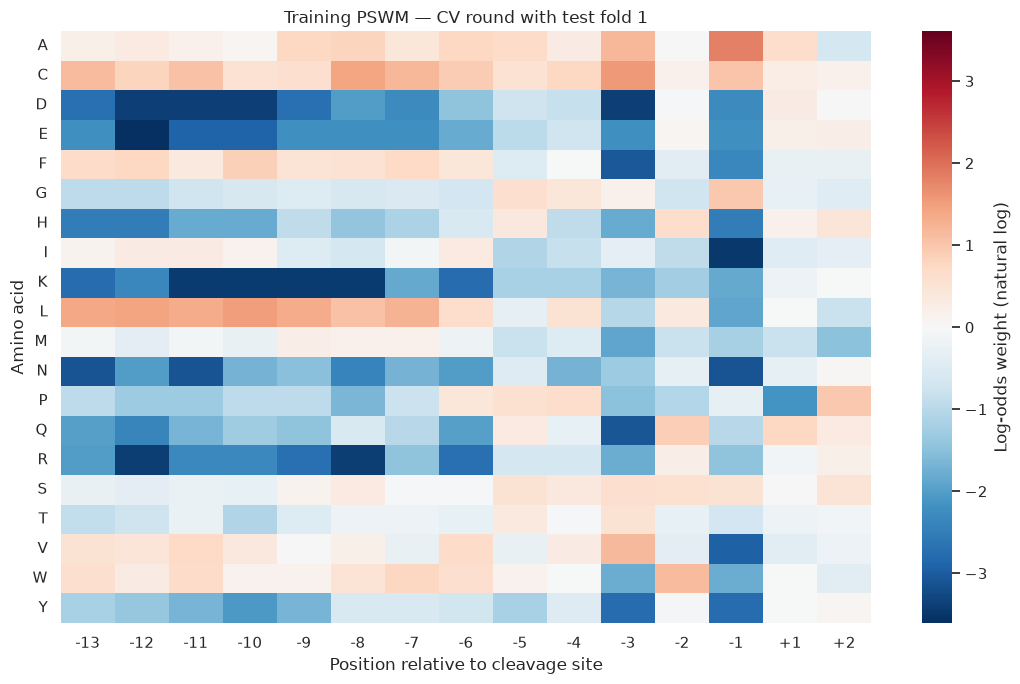

In [46]:
color_limit = np.abs(pswm_matrix.to_numpy()).max()
position_labels = [str(position) for position in range(-13, 0)] + ["+1", "+2"]

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    pswm_matrix, ax=ax, cmap="RdBu_r", center=0,
    vmin=-color_limit, vmax=color_limit,
    xticklabels=position_labels, yticklabels=True,
    cbar_kws={"label": "Log-odds weight (natural log)"}
)
ax.set_xlabel("Position relative to cleavage site")
ax.set_ylabel("Amino acid")
ax.set_title(f"Training PSWM — CV round with test fold {test_fold}")
ax.tick_params(axis="y", labelrotation=0)
fig.tight_layout()

figure_path = figure_dir / f"2_3_fold_{test_fold}_pswm.pdf"
fig.savefig(figure_path, format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_path)
plt.show()


## 3. Score N-terminal sequences

We sum position-specific weights for every complete window within the first 90 residues and retain the maximum score (slides 11 and 13). Shorter proteins use the available residues. The matrix determines the window length.

Non-canonical residues contribute zero without shifting positions. This is our scoring choice for residues outside the canonical alphabet. `best_start` records the window's 1-based starting position, rather than the cleavage position.

We retain each protein's metadata and add its global `score` and `best_start`.


In [47]:
n_terminal_length = 90


def score_sequence(sequence, pswm_df):
    weights = pswm_df.to_numpy()
    aa_index = {aa: i for i, aa in enumerate(pswm_df.index)}
    window_length = weights.shape[1]

    n_terminus = sequence[:n_terminal_length]
    best_score, best_start = -np.inf, None

    for start in range(len(n_terminus) - window_length + 1):
        window = n_terminus[start:start + window_length]
        score = 0.0 
        for position, aa in enumerate(window):
            if aa in aa_index:  # non-canonical residues contribute 0
                score += weights[aa_index[aa], position]
        if score > best_score:
            best_score, best_start = score, start + 1

    return best_score, best_start


def score_dataset(proteins, pswm_df):
    scored = proteins.copy()
    results = [score_sequence(sequence, pswm_df) for sequence in scored["sequence"]]
    scored["score"] = [score for score, _ in results]
    scored["best_start"] = [start for _, start in results]
    return scored

### 3.1 Score the validation proteins

We score both positive and negative proteins in validation fold 2 using the matrix estimated from training folds 3–5. The table retains accession, label and fold alongside the global score and best window's starting position.

The label and score arrays preserve the same row order. Test fold 1 and the independent benchmarking split remain separate from this calculation.


In [48]:
validation_scores = score_dataset(validation, pswm_matrix)

y_val = validation_scores["label"].to_numpy()
y_val_scores = validation_scores["score"].to_numpy()

validation_scores[["accession", "label", "cv_fold", "score", "best_start"]]


,accession,label,cv_fold,score,best_start
6,Q50KB1,1,2,10.191724,5
14,Q95UE8,1,2,7.821070,7
15,A7VN15,1,2,8.374104,7
17,O96059,1,2,9.316941,10
23,P14217,1,2,10.602725,9
...,...,...,...,...,...
10138,Q9R269,0,2,-5.808582,70
10152,Q62847,0,2,-0.930072,7
10156,P48608,0,2,2.103381,32
10170,Q6A078,0,2,-0.610458,28


### 3.2 Plot validation scores

We compare the global scores of positive and negative validation proteins using common histogram bins. Percentages are normalized independently within each class, so the larger negative class does not dominate the comparison. The blue/orange class colors follow 02c.

Each observation is one protein's maximum window score. Zero is a log-odds reference, not a classification threshold. The plot describes these validation scores; it does not measure classification performance.


Plot saved in: ../results/figures/03/3_2_fold_1_validation_scores.pdf


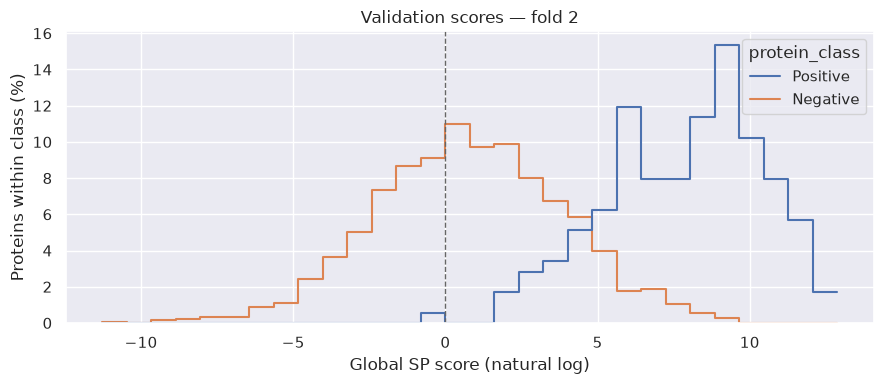

In [49]:
score_plot_data = validation_scores.assign(
    protein_class=validation_scores["label"].map({1: "Positive", 0: "Negative"})
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(
    data=score_plot_data, x="score", hue="protein_class",
    hue_order=["Positive", "Negative"],
    palette={"Positive": "C0", "Negative": "C1"},
    bins=30, common_bins=True,
    stat="percent", common_norm=False,
    element="step", fill=False, ax=ax
)
ax.axvline(0, color="0.4", linewidth=1, linestyle="--")
ax.set_xlabel("Global SP score (natural log)")
ax.set_ylabel("Proteins within class (%)")
ax.set_title(f"Validation scores — fold {test_fold % 5 + 1}")
fig.tight_layout()

figure_path = figure_dir / f"3_2_fold_{test_fold}_validation_scores.pdf"
fig.savefig(figure_path, format="pdf", bbox_inches="tight")
print("Plot saved in:", figure_path)
plt.show()
